In [1]:
#%pylab nbaggpython
%matplotlib inline
#%matplotlib widget
import numpy as np
from brian2 import *
import scipy.fftpack
from brian2.units.constants import faraday_constant as F
import time
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from pytictoc import TicToc

In [2]:
import pickle

def save_obj(obj, name ):
    with open('/Users/giovanni/Documents/GitHub/fufo/data/Interim/Abhirup/'+ name + '.pkl', 'wb') as f:
        pickle.dump(obj, f, pickle.HIGHEST_PROTOCOL)

In [3]:
import pickle
def load_obj(name ):
    with open('/Users/giovanni/Documents/GitHub/fufo/data/Interim/Abhirup/' + name + '.pkl', 'rb') as f:
        return pickle.load(f)

# Settings Mean Field Model

In [4]:
# Carmela

Par = {'Cnap': 21.0,  # mol.m**-3 
       'DCnap': 2.0,  # mol.m**-3 
       'Ckp': 5.5,  # mol.m**-3 
       'DCkp': 1.0,  # mol.m**-3 
       'Cmna': -24.0,  # mV 
       'DCmna': 12.0,  # mV 
       'Chn': 0.4,  # dimensionless 
       'DChn': -8.0,  # dimensionless 
       'Cnk': -19.0,  # mV 
       'DCnk': 18.0,  # mV #Ok in the paper
       'g_Cl': 7.5,  # nS #Ok in the paper
       'g_Na': 40.0,  # nS 
       'g_K': 22.0,  # nS 
       'g_Nal': 0.02,  # nS 
       'g_Kl': 0.12,  # nS 
       'rho': 250.,  # 250.,#pamp 
       'w_i': 2160.0,  # umeter 
       'w_o': 720.0,  # umeter 
       'K_bath': 12.5,  # mol.m**-3
       'Na_i0': 16.0,  # mol.m**-3 
       'Na_o0': 138.0,  # mol.m**-3 
       'K_i0': 130.0,  # mol.m**-3 
       'K_o0': 4.80,  # mol.m**-3 
       'Cl_o0': 112.0,  # mol.m**-3 
       'Cl_i0': 5.0,  # mol.m**-3 
       'E': 0., #check
       
       ## Time costants
       'Cm': 1,
       'tau_n': 4,
       'gamma': 0.04,  
       'epsilon': 0.001,
       'tau_I': 1
      }

In [5]:
def m_inf(V):
    return 1.0/(1.0+exp((Par['Cmna']-V)/Par['DCmna']))

def n_inf(V):
    return 1.0/(1.0+exp((Par['Cnk']-V)/Par['DCnk']))

def h(n):
    return 1.1 - 1.0 / (1.0 + np.exp(-8.0 * (n - 0.4)))

def I_K_form(V,n,K_o,K_i):
    return (Par['g_Kl']+Par['g_K']*n)*(V- 26.64*log(K_o/K_i)) 

def I_Na_form(V,Na_o,Na_i,n):
    return (Par['g_Nal']+Par['g_Na']*m_inf(V)*h(n))*(V- 26.64*log(Na_o/Na_i))

def I_Cl_form(V):
    return Par['g_Cl']*(V+ 26.64*log(Par['Cl_o0']/Par['Cl_i0'])) 

def I_pump_form(Na_i,K_o):
    return Par['rho']*(1.0/(1.0+exp((Par['Cnap'] - Na_i) / Par['DCnap']))*(1.0/(1.0+exp((Par['Ckp'] - K_o)/Par['DCkp'])))) 

def V_dot_form(I_Na,I_K,I_Cl,I_pump):
    return (-1.0/Par['Cm'])*(I_Na+I_K+I_Cl+I_pump) 

In [6]:
def mean_field_model(z,t,kb,eta,J,Delta,Vstar,c_minus,c_plus,R_minus,R_plus):
    
    x = z[0]
    V = z[1]
    n = z[2]
    DK_i = z[3]
    Kg = z[4]
        
    K_bath= kb
    eta_bar_val= eta
    
    beta= Par['w_i'] / Par['w_o'] 
    DNa_i = -DK_i 
    DNa_o = -beta * DNa_i
    DK_o = -beta * DK_i
    K_i = Par['K_i0'] + DK_i 
    Na_i = Par['Na_i0'] + DNa_i 
    Na_o = Par['Na_o0'] + DNa_o 
    K_o = Par['K_o0'] + DK_o + Kg 
    
    I_K = I_K_form(V,n,K_o,K_i)
    I_Na = I_Na_form(V,Na_o,Na_i,n)
    I_Cl = I_Cl_form(V)
    I_pump = I_pump_form(Na_i,K_o)

    #%%%%%% Equations      
    Vdot = (-1.0/Par['Cm'])*(I_Na+I_K+I_Cl+I_pump)    
    
    if V <= Vstar:
        dV = Vdot - R_minus*x**2 + eta_bar_val
        dx = Delta + 2*R_minus*(V-c_minus)*x
        
    else:
        dV = Vdot - R_plus*x**2 + eta_bar_val
        dx = Delta + 2*R_plus*(V-c_plus)*x
        
    rr=R_minus*x/np.pi
    
    dV+= J*(rr)*(Par['E']-V)
    dx+= -J*(rr)*x
    
    ninf=n_inf(V)
    dn = (ninf - n) / Par['tau_n'] 
    dDK_i = -(Par['gamma'] / Par['w_i']) * (I_K - 2.0 * I_pump)
    dKg = Par['epsilon'] * (K_bath - K_o)
    
    dz = [dx,dV,dn,dDK_i,dKg]

    return dz   

# Setting simulation

In [7]:
# Simulation time
min_2_sim=1/3
min_2_cut=0
Np= int(min_2_sim*60*1000) #min in milliseconds 
Np_left= int(min_2_cut*60*1000) #min in milliseconds 
t = np.linspace(0,Np,Np*1)

In [8]:
#Parabolas coefficients
c_minus=-44.240
c_plus=-20.400
R_minus=0.337
R_plus=-0.381
Vstar=-31

In [9]:
# Meanfield Parameters
J_vec = [1]
eta_vec = [0.]
Delta= 1.

In [10]:
k=15.5 # K bath value

#Initial Conditions [x, V, n, DKi, Kg]
z0 = [0.1,-15.0, 0.45, -3.5, -12.0]

# Parabolas coefficients exploration

In [11]:
RM=np.logspace(-3,0,31)
RP=-np.logspace(-3,0,31)[::-1]
CM=np.linspace(-70,-40,31)
CP=np.linspace(-27,-10,31)
VS=np.linspace(-50,-18,31)

In [12]:
# Meanfield_cminus={}
# for icm, cm in enumerate(CM):
#     print(cm)
#     Meanfield_cminus[cm]={} 
#     z = odeint(mean_field_model,z0,t, args=(k,eta_vec[0],J_vec[0],Delta,Vstar,cm,c_plus,R_minus,R_plus,))

#     Meanfield_cminus[cm]={} 
#     Meanfield_cminus[cm]['x']=z[:,0]
#     Meanfield_cminus[cm]['V']=z[:,1]
#     Meanfield_cminus[cm]['n']=z[:,2]
#     Meanfield_cminus[cm]['DK_i']=z[:,3]
#     Meanfield_cminus[cm]['Kg']=z[:,4]

#     save_obj(Meanfield_cminus,'Meanfield_cminusJ10')
    
# Meanfield_cplus={}
# for icp, cp in enumerate(CP):
#     print(cp)
#     Meanfield_cplus[cp]={} 
#     z = odeint(mean_field_model,z0,t, args=(k,eta_vec[0],J_vec[0],Delta,Vstar,c_minus,cp,R_minus,R_plus,))

#     Meanfield_cplus[cp]={} 
#     Meanfield_cplus[cp]['x']=z[:,0]
#     Meanfield_cplus[cp]['V']=z[:,1]
#     Meanfield_cplus[cp]['n']=z[:,2]
#     Meanfield_cplus[cp]['DK_i']=z[:,3]
#     Meanfield_cplus[cp]['Kg']=z[:,4]

#     save_obj(Meanfield_cplus,'Meanfield_cplusJ10')
    
# Meanfield_Rminus={}
# for irm, rm in enumerate(RM):
#     print(rm)
#     Meanfield_Rminus[rm]={} 
#     z = odeint(mean_field_model,z0,t, args=(k,eta_vec[0],J_vec[0],Delta,Vstar,c_minus,c_plus,rm,R_plus,))

#     Meanfield_Rminus[rm]={} 
#     Meanfield_Rminus[rm]['x']=z[:,0]
#     Meanfield_Rminus[rm]['V']=z[:,1]
#     Meanfield_Rminus[rm]['n']=z[:,2]
#     Meanfield_Rminus[rm]['DK_i']=z[:,3]
#     Meanfield_Rminus[rm]['Kg']=z[:,4]

#     save_obj(Meanfield_Rminus,'Meanfield_RminusJ10')
    
# Meanfield_Rplus={}
# for irp, rp in enumerate(RP):
#     print(rp)
#     Meanfield_Rplus[rp]={} 
#     z = odeint(mean_field_model,z0,t, args=(k,eta_vec[0],J_vec[0],Delta,Vstar,c_minus,c_plus,R_minus,rp,))

#     Meanfield_Rplus[rp]={} 
#     Meanfield_Rplus[rp]['x']=z[:,0]
#     Meanfield_Rplus[rp]['V']=z[:,1]
#     Meanfield_Rplus[rp]['n']=z[:,2]
#     Meanfield_Rplus[rp]['DK_i']=z[:,3]
#     Meanfield_Rplus[rp]['Kg']=z[:,4]

    save_obj(Meanfield_Rplus,'Meanfield_RplusJ10')


# J=10

In [30]:
Meanfield_cminusJ10=load_obj('Meanfield_cminusJ10')

Meanfield_cplusJ10=load_obj('Meanfield_cplusJ10')

Meanfield_RminusJ10=load_obj('Meanfield_RminusJ10')

Meanfield_RplusJ10=load_obj('Meanfield_RplusJ10')

In [31]:
sizx=2.8
sizy=1.55
titsiz=8
labsiz=5

In [32]:
spec_cm=np.zeros((len(CM),513))
spec_rm=np.zeros((len(RM),513))
spec_cp=np.zeros((len(CP),513))
spec_rp=np.zeros((len(RP),513))
for ii, i in enumerate(CM):
    sig=Meanfield_cminusJ10[i]['V']
    freqs, spec_cm[ii,:]=signal.welch(sig,fs=1000,nperseg=1024)
for ii, i in enumerate(CP):
    sig=Meanfield_cplusJ10[i]['V']
    freqs, spec_cp[ii,:]=signal.welch(sig,fs=1000,nperseg=1024)
for ii, i in enumerate(RM):
    sig=Meanfield_RminusJ10[i]['V']
    freqs, spec_rm[ii,:]=signal.welch(sig,fs=1000,nperseg=1024)
for ii, i in enumerate(RP):
    sig=Meanfield_RplusJ10[i]['V']
    freqs, spec_rp[ii,:]=signal.welch(sig,fs=1000,nperseg=1024)

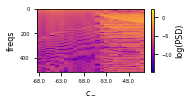

In [33]:
plt.figure(figsize=(sizx,sizy))
plt.imshow(np.log(spec_cm[2:-5,:]).T,aspect='auto',cmap='plasma',interpolation='none')
cbar = plt.colorbar()
cbar.set_label('log(PSD)',fontsize=titsiz)
cbar.ax.tick_params(labelsize=labsiz)
plt.xticks(np.arange(len(CM[2:-5]))[::5],CM[2:-5][::5],fontsize=labsiz)
plt.yticks(fontsize=labsiz)
plt.ylabel('freqs',fontsize=titsiz)
plt.xlabel('$c_-$',fontsize=titsiz)
plt.tight_layout()
#plt.savefig('Figures/PSD_cminus.pdf')
plt.show()

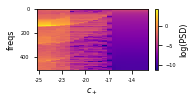

In [34]:
plt.figure(figsize=(sizx,sizy))
plt.imshow(np.log(spec_cp[2:-5,:]).T,aspect='auto',cmap='plasma',interpolation='none')
cbar = plt.colorbar()
cbar.set_label('log(PSD)',fontsize=titsiz)
cbar.ax.tick_params(labelsize=labsiz)
plt.xticks(np.arange(len(CP[2:-5]))[::5],CP[2:-5][::5].astype(int),fontsize=labsiz)
plt.yticks(fontsize=labsiz)
plt.ylabel('freqs',fontsize=titsiz)
plt.xlabel('$c_+$',fontsize=titsiz)
plt.tight_layout()
#plt.savefig('Figures/PSD_cplus.pdf')
plt.show()

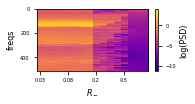

In [35]:
plt.figure(figsize=(sizx,sizy))
plt.imshow(np.log(spec_rm[15:,:]).T,aspect='auto',cmap='plasma',interpolation='none')
cbar = plt.colorbar()
cbar.set_label('log(PSD)',fontsize=titsiz)
cbar.ax.tick_params(labelsize=labsiz)
plt.xticks(np.arange(len(RM[15:]))[::4],RM[15:][::4].round(2),fontsize=labsiz)
plt.yticks(fontsize=labsiz)
plt.ylabel('freqs',fontsize=titsiz)
plt.xlabel('$R_-$',fontsize=titsiz)
plt.tight_layout()
#plt.savefig('Figures/PSD_Rminus.pdf')
plt.show()

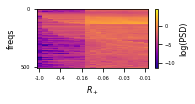

In [36]:
plt.figure(figsize=(sizx,sizy))
plt.imshow(np.log(spec_rp[:-10,:]).T,aspect='auto',cmap='plasma',interpolation='none')
cbar = plt.colorbar()
cbar.set_label('log(PSD)',fontsize=titsiz)
cbar.ax.tick_params(labelsize=labsiz)
plt.xticks(np.arange(len(RP[:-10]))[::4],RP[:-10][::4].round(2),fontsize=labsiz)
plt.yticks(fontsize=labsiz)
plt.ylabel('freqs',fontsize=titsiz)
plt.xlabel('$R_+$',fontsize=titsiz)
plt.tight_layout()
#plt.savefig('Figures/PSD_Rplus.pdf')
plt.show()

#  J=1

In [13]:
Meanfield_cminusJ1=load_obj('Meanfield_cminus')
#Meanfield_cminusJ10=load_obj('Meanfield_cminusJ10')

Meanfield_cplusJ1=load_obj('Meanfield_cplus')
#Meanfield_cplusJ10=load_obj('Meanfield_cplusJ10')

Meanfield_RminusJ1=load_obj('Meanfield_Rminus')
#Meanfield_RminusJ10=load_obj('Meanfield_RminusJ10')

Meanfield_RplusJ1=load_obj('Meanfield_Rplus')
#Meanfield_RplusJ10=load_obj('Meanfield_RplusJ10')

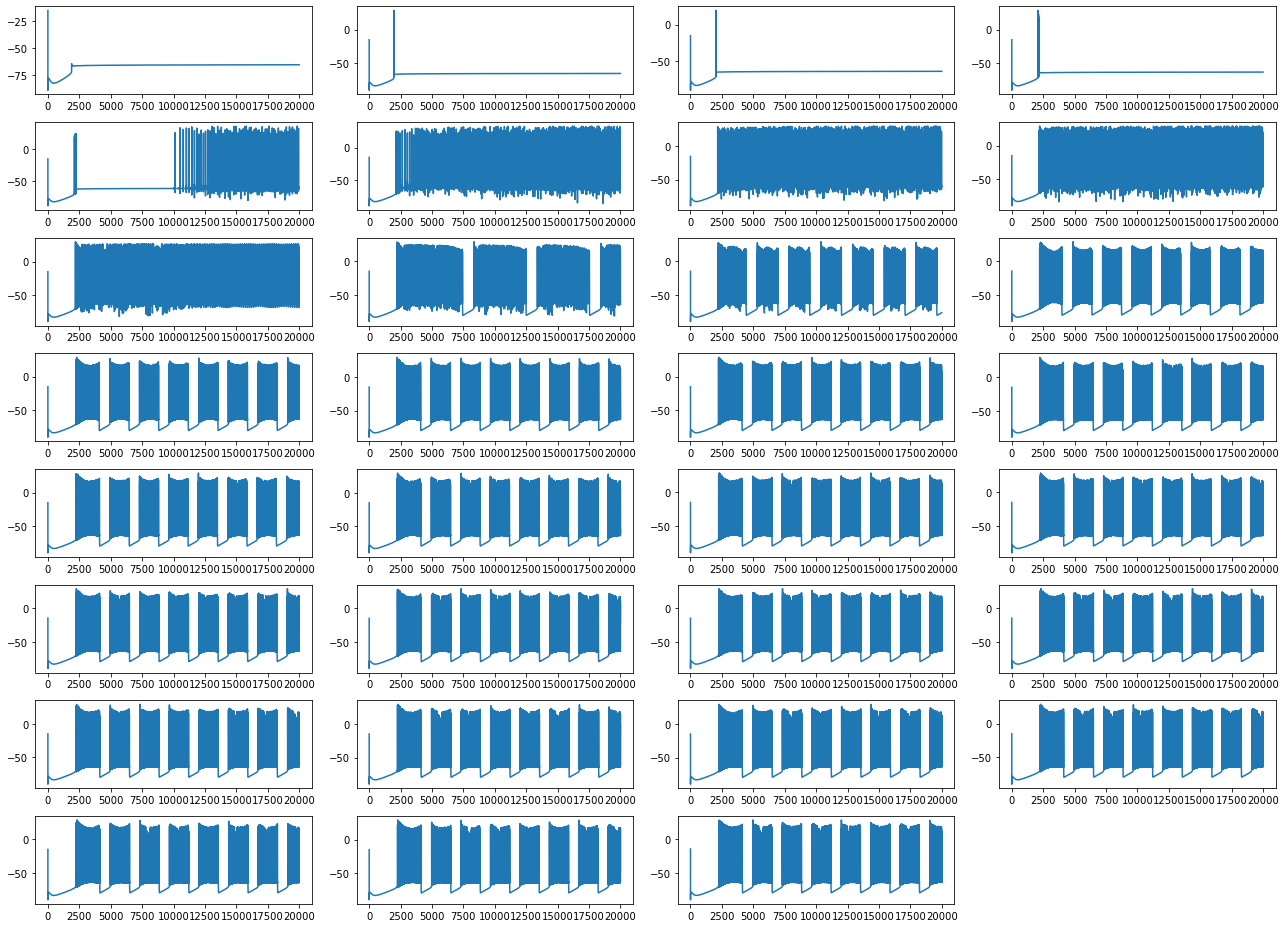

In [14]:
plt.figure(figsize=(18,13))
for icm, cm in enumerate(CM):
    plt.subplot(8,4,icm+1)
    plt.plot(Meanfield_cminusJ1[cm]['V'])[::10]
plt.tight_layout()
plt.show()

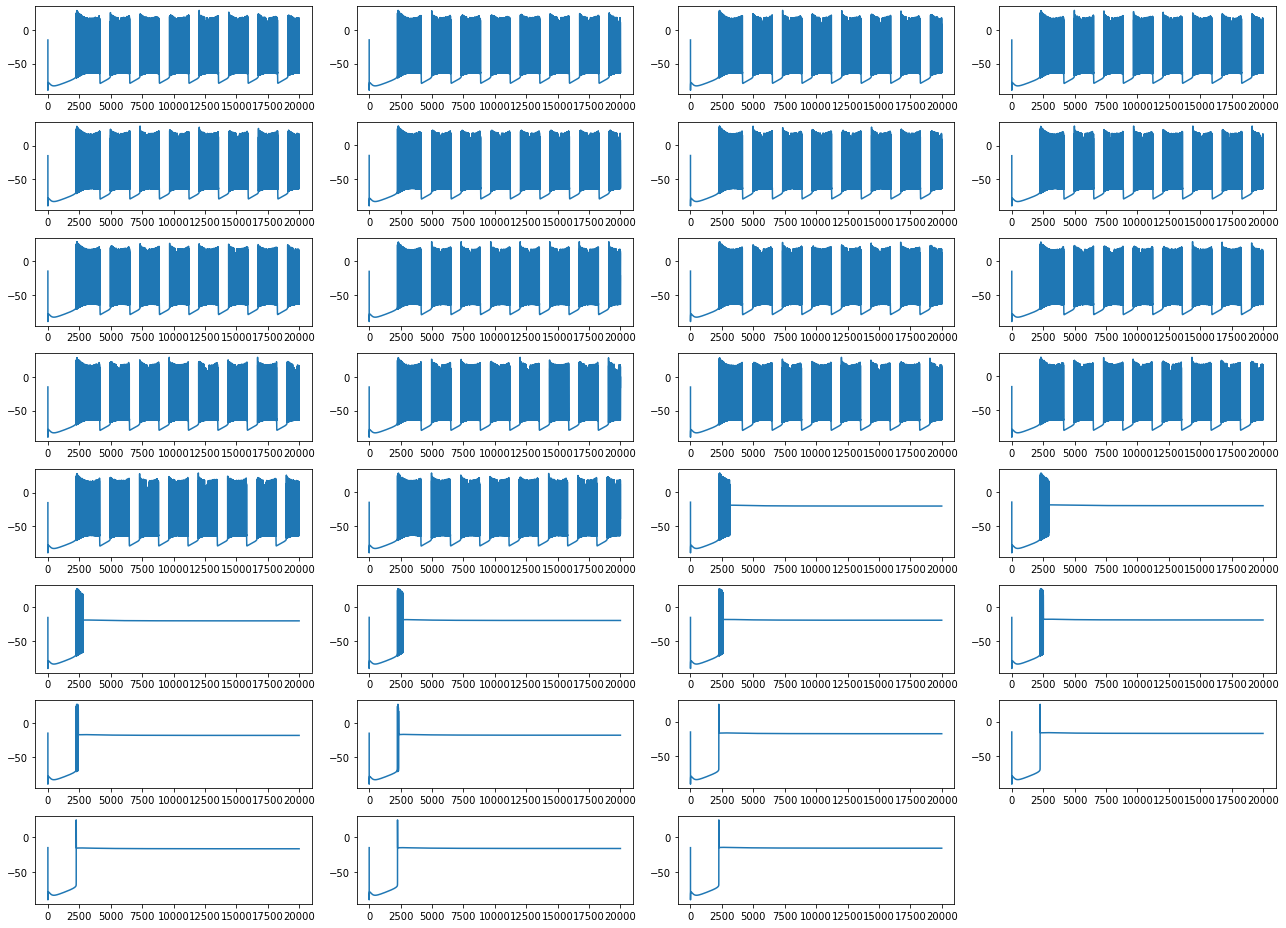

In [16]:
plt.figure(figsize=(18,13))
for icp, cp in enumerate(CP):
    plt.subplot(8,4,icp+1)
    plt.plot(Meanfield_cplusJ1[cp]['V'])[::10]
plt.tight_layout()
plt.show()

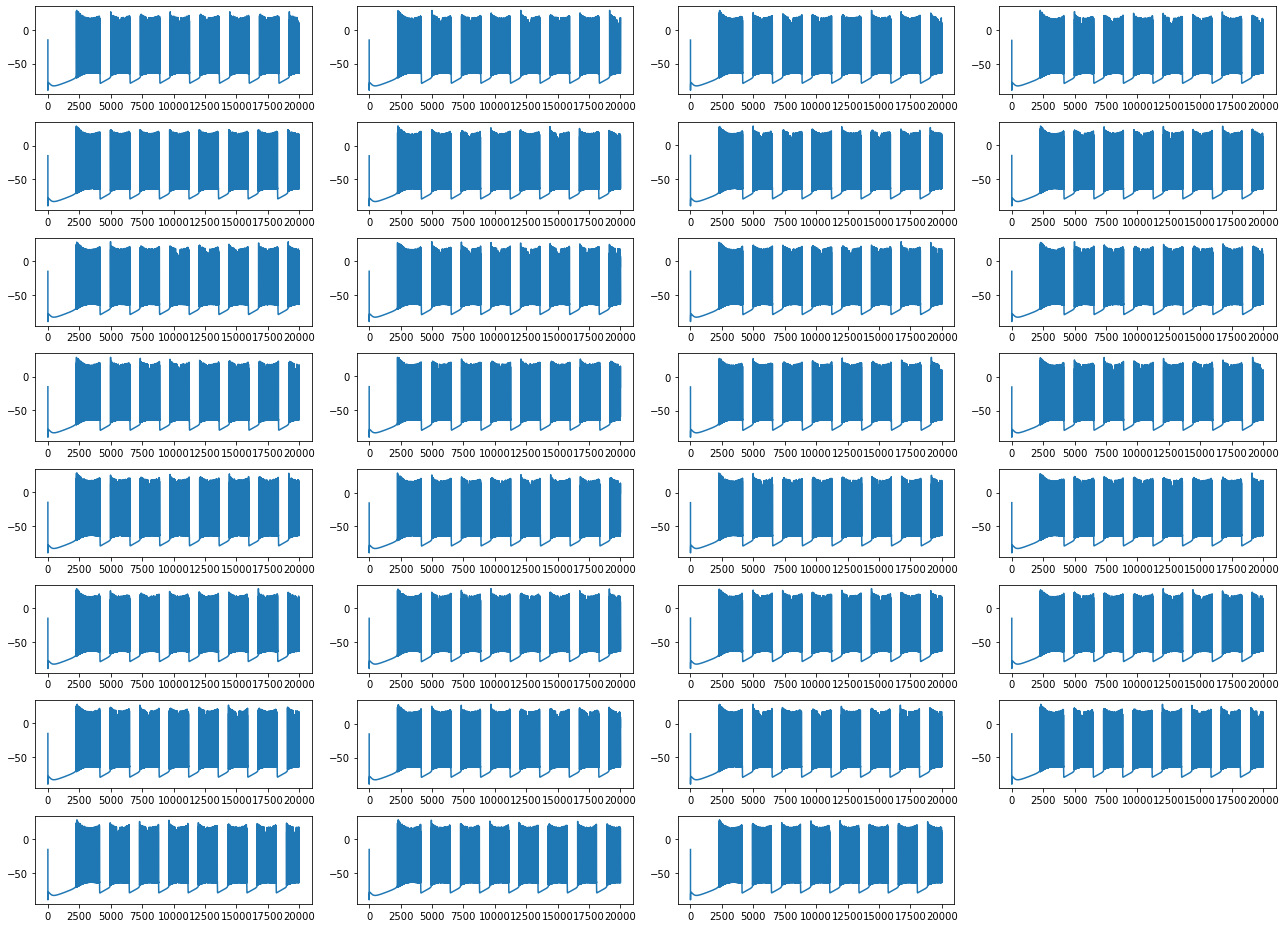

In [18]:
plt.figure(figsize=(18,13))
for irm, rm in enumerate(RM):
    plt.subplot(8,4,irm+1)
    plt.plot(Meanfield_RminusJ1[rm]['V'])[::10]
plt.tight_layout()
plt.show()

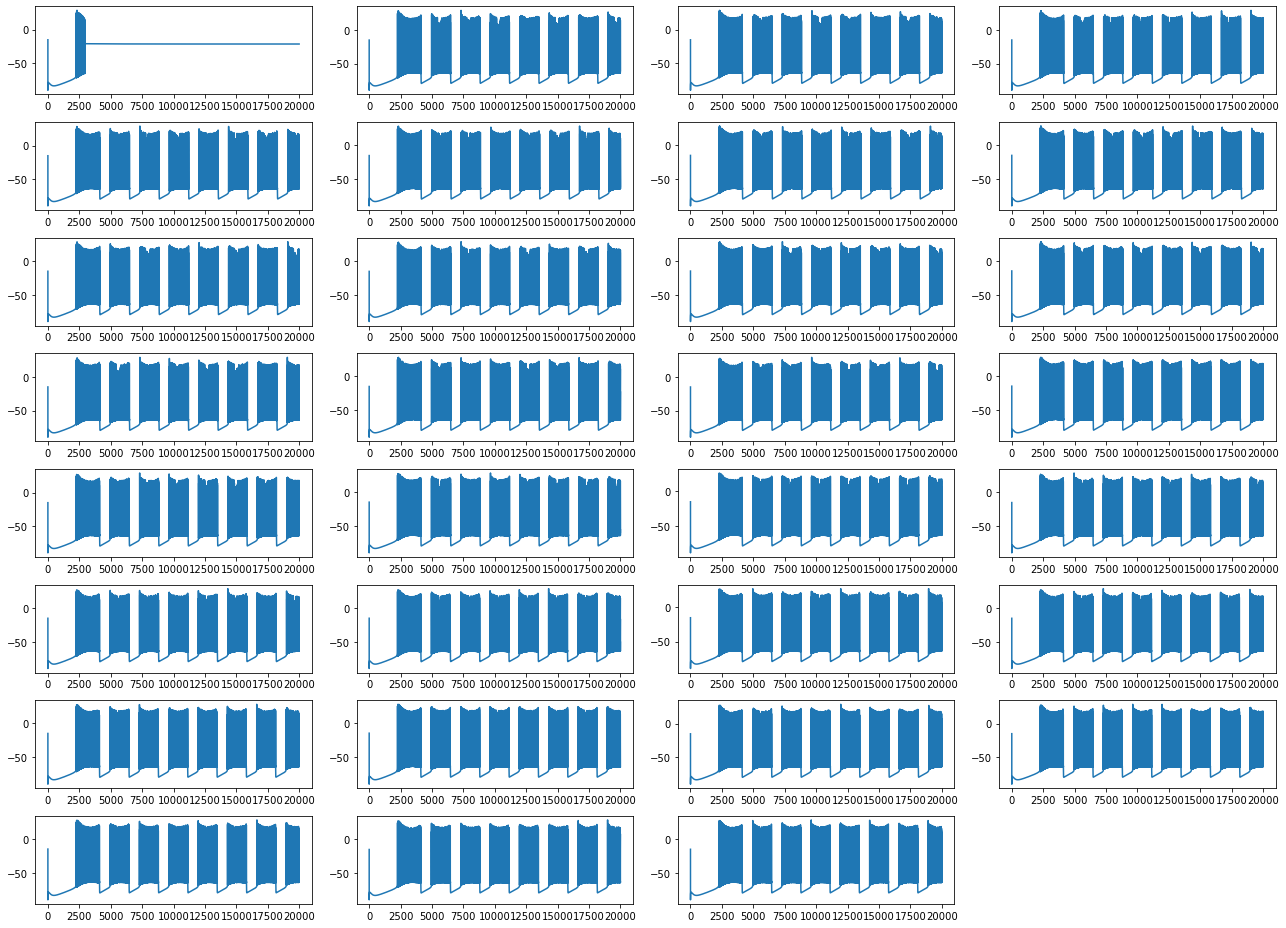

In [17]:
plt.figure(figsize=(18,13))
for irp, rp in enumerate(RP):
    plt.subplot(8,4,irp+1)
    plt.plot(Meanfield_RplusJ1[rp]['V'])[::10]
plt.tight_layout()
plt.show()

# Double pulse

In [200]:
# Simulation time
min_2_sim=2
min_2_cut=0
Np= int(min_2_sim*60*1000) #min in milliseconds 
Np_left= int(min_2_cut*60*1000) #min in milliseconds 
t = np.linspace(0,Np,Np*10)

In [201]:
#Parabolas coefficients
c_minus=-44.240
c_plus=-20.400
R_minus=0.337
R_plus=-0.381
Vstar=-31

In [202]:
# Meanfield Parameters
J_vec = [15]
eta_vec = [-1.]
Delta= 4.

In [203]:
k=5 # K bath value

#Initial Conditions [x, V, n, DKi, Kg]
z0 = [0.1,-15.0, 0.45, -3.5, -12.0]

In [204]:
Meanfield_apero={}
z = odeint(mean_field_model,z0,t, args=(k,eta_vec[0],J_vec[0],Delta,Vstar,c_minus,c_plus,R_minus,R_plus,))

# Meanfield_apero['x']=z[:,0]
# Meanfield_apero['V']=z[:,1]
# Meanfield_apero['n']=z[:,2]
# Meanfield_apero['DK_i']=z[:,3]
# Meanfield_apero['Kg']=z[:,4]

#save_obj(Meanfield_apero,'Meanfield_apero')

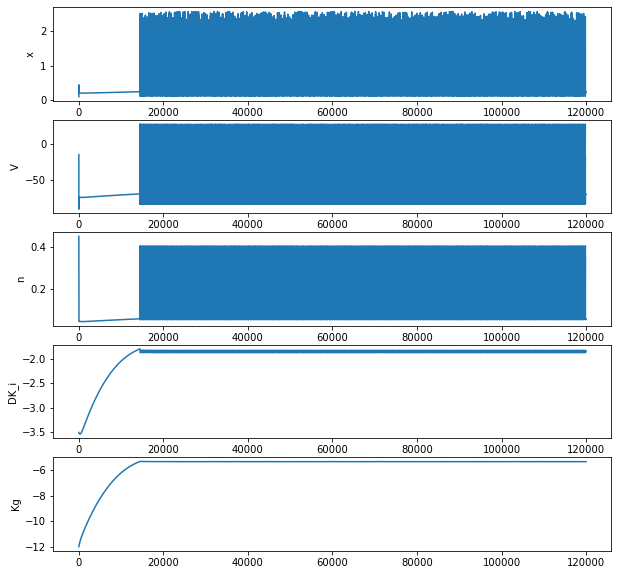

In [205]:
#c_minus=CM[4]
fig, axs = plt.subplots(5, 1, figsize=(10,10))
axs[0].plot(t[::1], z[::1,0]);axs[0].set_ylabel('x')
axs[1].plot(t[::1], z[::1,1]);axs[1].set_ylabel('V')
axs[2].plot(t[::1], z[::1,2]);axs[2].set_ylabel('n')
axs[3].plot(t[::1], z[::1,3]); axs[3].set_ylabel('DK_i')
axs[4].plot(t[::1], z[::1,4]);axs[4].set_ylabel('Kg')
plt.show()

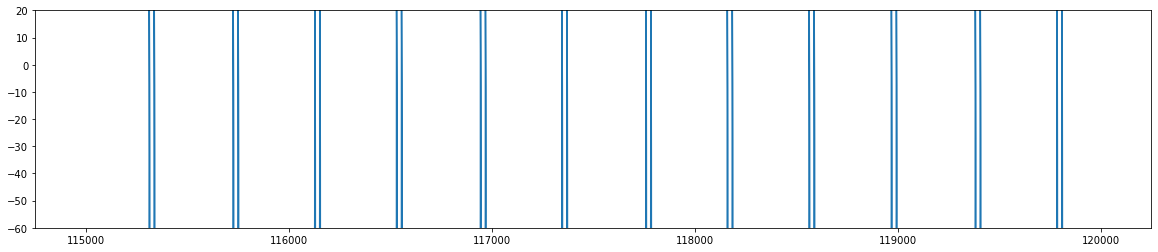

In [218]:
#c_minus=CM[4]
plt.figure(figsize=(20,4))
plt.plot(t[1150000:], z[1150000:,1]);
plt.ylim((-60,20))
plt.show()

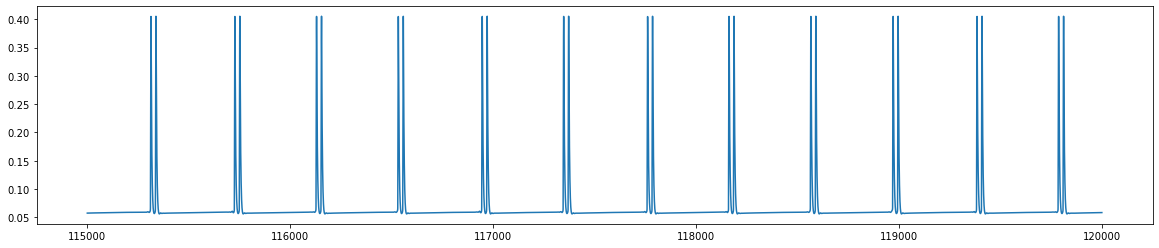

In [220]:
#c_minus=CM[4]
plt.figure(figsize=(20,4))
plt.plot(t[1150000:], z[1150000:,2]);
#plt.ylim((-60,20))
plt.show()

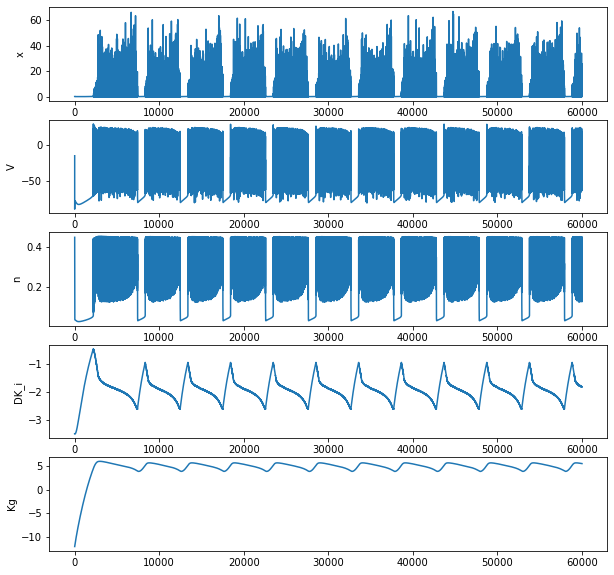

In [44]:
#c_minus=CM[9]
fig, axs = plt.subplots(5, 1, figsize=(10,10))
axs[0].plot(t[::1], z[::1,0]);axs[0].set_ylabel('x')
axs[1].plot(t[::1], z[::1,1]);axs[1].set_ylabel('V')
axs[2].plot(t[::1], z[::1,2]);axs[2].set_ylabel('n')
axs[3].plot(t[::1], z[::1,3]); axs[3].set_ylabel('DK_i')
axs[4].plot(t[::1], z[::1,4]);axs[4].set_ylabel('Kg')
plt.show()

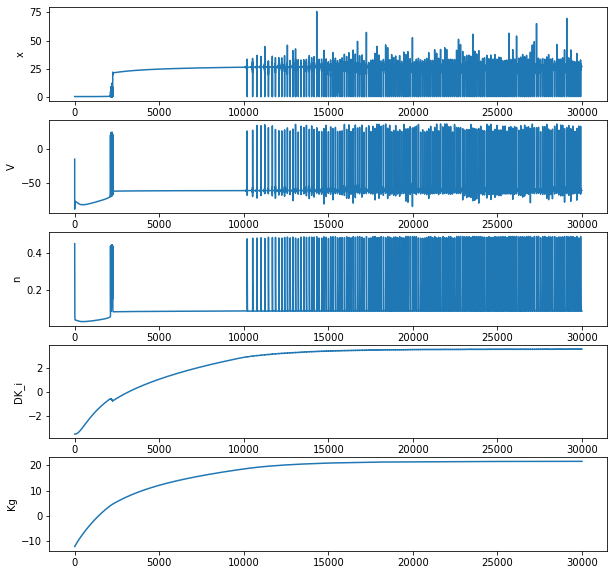

In [51]:
#c_minus=CM[4]
fig, axs = plt.subplots(5, 1, figsize=(10,10))
axs[0].plot(t[::1], z[::1,0]);axs[0].set_ylabel('x')
axs[1].plot(t[::1], z[::1,1]);axs[1].set_ylabel('V')
axs[2].plot(t[::1], z[::1,2]);axs[2].set_ylabel('n')
axs[3].plot(t[::1], z[::1,3]); axs[3].set_ylabel('DK_i')
axs[4].plot(t[::1], z[::1,4]);axs[4].set_ylabel('Kg')
plt.show()

# PSD

In [19]:
from scipy import signal


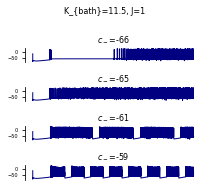

In [20]:
sig=Meanfield_cminusJ1[CM[4]]['V']#Meanfield_cplus[CP[0]]['V']
sig2=Meanfield_cminusJ1[CM[5]]['V']#Meanfield_cplus[CP[5]]['V']#Meanfield_Rplus[rp]['V']
sig3=Meanfield_cminusJ1[CM[9]]['V']#Meanfield_cplus[CP[5]]['V']#Meanfield_Rplus[rp]['V']
sig4=Meanfield_cminusJ1[CM[11]]['V']#Meanfield_cplus[CP[5]]['V']#Meanfield_Rplus[rp]['V']

fig = plt.figure(figsize=(3,2.6))
plt.suptitle('K_{bath}=11.5, J=1',fontsize=8)
ax1 = fig.add_subplot(411)
ax1.plot(sig,c='navy',linewidth=1,label='$c_-$=%d'%CM[4])
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=5)
ax1.set_title('$c_-$=%d'%CM[4],fontsize=8)

ax1 = fig.add_subplot(412)
ax1.plot(sig2,c='navy',linewidth=1,label='$c_-$=%d'%CM[5])
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=5)
ax1.set_title('$c_-$=%d'%CM[5],fontsize=8)

ax1 = fig.add_subplot(413)
ax1.plot(sig3,c='navy',linewidth=1,label='$c_-$=%d'%CM[9])
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=5)
ax1.set_title('$c_-$=%d'%CM[9],fontsize=8)

ax1 = fig.add_subplot(414)
ax1.plot(sig4,c='navy',linewidth=1,label='$c_-$=%d'%CM[11])
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=5)
ax1.set_title('$c_-$=%d'%CM[11],fontsize=8)

plt.tight_layout()
#plt.savefig('Figures/Cminus_variations.pdf')
plt.show()

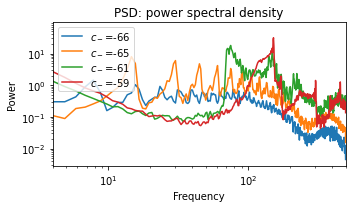

In [21]:
freqs, psd = signal.welch(sig,fs=1000,nperseg=1024)
freqs2, psd2 = signal.welch(sig2,fs=1000,nperseg=1024)
freqs3, psd3 = signal.welch(sig3,fs=1000,nperseg=1024)
freqs4, psd4 = signal.welch(sig4,fs=1000,nperseg=1024)

plt.figure(figsize=(5, 3))
plt.loglog(freqs, psd,label='$c_-$=%d'%CM[4])
plt.loglog(freqs2, psd2,label='$c_-$=%d'%CM[5])
plt.loglog(freqs3, psd3,label='$c_-$=%d'%CM[9])
plt.loglog(freqs4, psd4,label='$c_-$=%d'%CM[11])
plt.xlim((4,500))
#plt.ylim((0,35))
plt.title('PSD: power spectral density')
plt.xlabel('Frequency')
plt.ylabel('Power')
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
spec_cm=np.zeros((len(CM),513))
for ii, i in enumerate(CM):
    sig=Meanfield_cminusJ1[i]['V']
    freqs, spec_cm[ii,:]=signal.welch(sig,fs=1000,nperseg=1024)

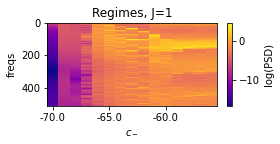

In [27]:
plt.figure(figsize=(4,2.1))
plt.title('Regimes, J=1')
plt.imshow(np.log(spec_cm[:15,:]).T,aspect='auto',cmap='plasma',interpolation='none')
cbar = plt.colorbar()
cbar.set_label('log(PSD)')
#plt.colorbar(label)
plt.xticks(np.arange(len(CM[:15]))[::5],CM[:15][::5])
plt.ylabel('freqs')
plt.xlabel('$c_-$')
plt.tight_layout()
plt.show()

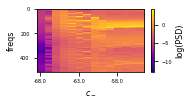

In [29]:
plt.figure(figsize=(sizx,sizy))
plt.imshow(np.log(spec_cm[2:-15,:]).T,aspect='auto',cmap='plasma',interpolation='none')
cbar = plt.colorbar()
cbar.set_label('log(PSD)',fontsize=titsiz)
cbar.ax.tick_params(labelsize=labsiz)
plt.xticks(np.arange(len(CM[2:-15]))[::5],CM[2:-15][::5],fontsize=labsiz)
plt.yticks(fontsize=labsiz)
plt.ylabel('freqs',fontsize=titsiz)
plt.xlabel('$c_-$',fontsize=titsiz)
plt.tight_layout()
#plt.savefig('Figures/PSD_cminus.pdf')
plt.show()

In [189]:
spec_cm.shape

(31, 513)

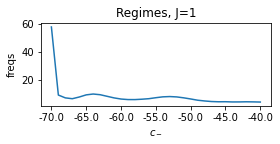

In [198]:
plt.figure(figsize=(4,2.1))
plt.title('Regimes, J=1')
plt.plot(np.max(spec_cm,axis=1))
plt.xticks(np.arange(len(CM[:]))[::5],CM[:][::5])
plt.ylabel('freqs')
plt.xlabel('$c_-$')
plt.tight_layout()
plt.show()

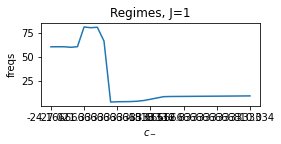

In [199]:
plt.figure(figsize=(4,2.1))
plt.title('Regimes, J=1')
plt.plot(np.max(spec_cp,axis=1))
plt.xticks(np.arange(len(CP[:]))[::5],CP[:][::5])
plt.ylabel('freqs')
plt.xlabel('$c_-$')
plt.tight_layout()
plt.show()

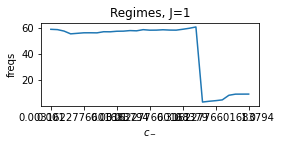

In [200]:
plt.figure(figsize=(4,2.1))
plt.title('Regimes, J=1')
plt.plot(np.max(spec_rm,axis=1))
plt.xticks(np.arange(len(RM[:]))[::5],RM[:][::5])
plt.ylabel('freqs')
plt.xlabel('$c_-$')
plt.tight_layout()
plt.show()

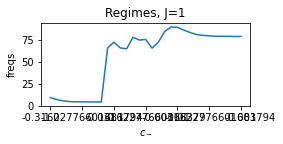

In [201]:
plt.figure(figsize=(4,2.1))
plt.title('Regimes, J=1')
plt.plot(np.max(spec_rp,axis=1))
plt.xticks(np.arange(len(RP[:]))[::5],RP[:][::5])
plt.ylabel('freqs')
plt.xlabel('$c_-$')
plt.tight_layout()
plt.show()

# Single parameter example

In [6]:
J_vec = [1.]
eta_vec = [0.]
Delta= 1.

Vstar=-31
kb=15.5

#iii=4
#c_minus=Cm_c2[iii]*kb**2+Cm_c1[iii]*kb+Cm_c0[iii]
#c_plus=Cp_c2[iii]*kb**2+Cp_c1[iii]*kb+Cp_c0[iii]
#R_minus=Rm_c2[iii]*kb**2+Rm_c1[iii]*kb+Rm_c0[iii]
#R_plus=Rp_c2[iii]*kb**2+Rp_c1[iii]*kb+Rp_c0[iii]

In [218]:
z0 = [0.1,-15.0, 0.45, -3.5, -12.0]

min_2_sim=1/3
min_2_cut=0
Np= int(min_2_sim*60*1000) #min in milliseconds 
Np_left= int(min_2_cut*60*1000) #min in milliseconds 
t = np.linspace(0,Np,Np*1)

tic = time.time()
Meanfield={}

z = odeint(mean_field_model,z0,t, args=(kb, eta_vec[0],J_vec[0],Delta,Vstar,c_minus,c_plus,R_minus,R_plus,))

Meanfield[kb]={} 
Meanfield[kb]['x']=z[::10,0]
Meanfield[kb]['V']=z[::10,1]
Meanfield[kb]['n']=z[::10,2]
Meanfield[kb]['DK_i']=z[::10,3]
Meanfield[kb]['Kg']=z[::10,4]
tac = time.time()
elapsed_time = tac-tic
print('Elapsed time:')
time.strftime("%H:%M:%S", time.gmtime(elapsed_time))

Elapsed time:


'00:00:02'

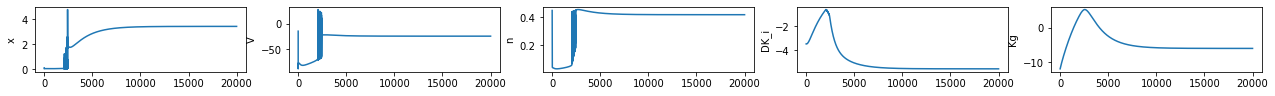

In [219]:
#J=1, Kb=15.5 
fig, axs = plt.subplots(1, 5, figsize=(22,1.2))
axs[0].plot(t[::1], z[::1,0]);axs[0].set_ylabel('x')
axs[1].plot(t[::1], z[::1,1]);axs[1].set_ylabel('V')
axs[2].plot(t[::1], z[::1,2]);axs[2].set_ylabel('n')
axs[3].plot(t[::1], z[::1,3]); axs[3].set_ylabel('DK_i')
axs[4].plot(t[::1], z[::1,4]);axs[4].set_ylabel('Kg')
plt.show()

In [149]:
#J=0.1

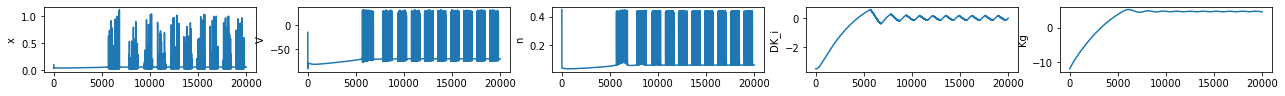

In [163]:
#J=0, Kb=9.5
fig, axs = plt.subplots(1, 5, figsize=(22,1.2))
axs[0].plot(t[::1], z[::1,0]);axs[0].set_ylabel('x')
axs[1].plot(t[::1], z[::1,1]);axs[1].set_ylabel('V')
axs[2].plot(t[::1], z[::1,2]);axs[2].set_ylabel('n')
axs[3].plot(t[::1], z[::1,3]); axs[3].set_ylabel('DK_i')
axs[4].plot(t[::1], z[::1,4]);axs[4].set_ylabel('Kg')
plt.show()

In [149]:
#J=0

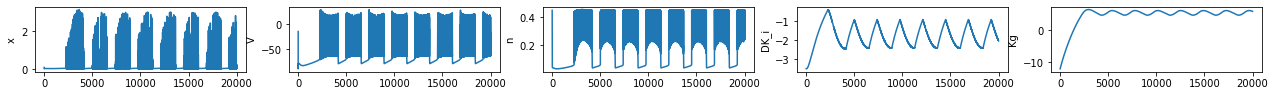

In [159]:
#J=0, Kb=15.5
fig, axs = plt.subplots(1, 5, figsize=(22,1.2))
axs[0].plot(t[::1], z[::1,0]);axs[0].set_ylabel('x')
axs[1].plot(t[::1], z[::1,1]);axs[1].set_ylabel('V')
axs[2].plot(t[::1], z[::1,2]);axs[2].set_ylabel('n')
axs[3].plot(t[::1], z[::1,3]); axs[3].set_ylabel('DK_i')
axs[4].plot(t[::1], z[::1,4]);axs[4].set_ylabel('Kg')
plt.show()

In [ ]:
#J=1

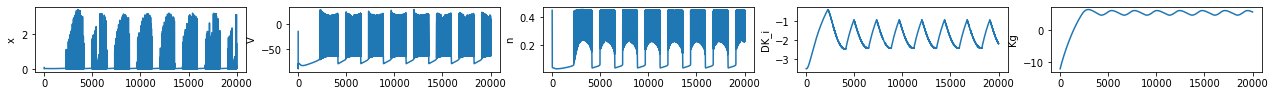

In [9]:
#J=1, Kb=15.5
fig, axs = plt.subplots(1, 5, figsize=(22,1.2))
axs[0].plot(t[::1], z[::1,0]);axs[0].set_ylabel('x')
axs[1].plot(t[::1], z[::1,1]);axs[1].set_ylabel('V')
axs[2].plot(t[::1], z[::1,2]);axs[2].set_ylabel('n')
axs[3].plot(t[::1], z[::1,3]); axs[3].set_ylabel('DK_i')
axs[4].plot(t[::1], z[::1,4]);axs[4].set_ylabel('Kg')
plt.show()

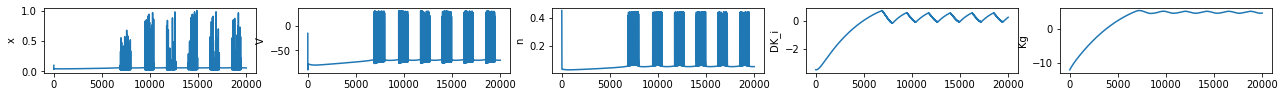

In [31]:
#J=1, Kb=8.75 (7.5)
fig, axs = plt.subplots(1, 5, figsize=(22,1.2))
axs[0].plot(t[::1], z[::1,0]);axs[0].set_ylabel('x')
axs[1].plot(t[::1], z[::1,1]);axs[1].set_ylabel('V')
axs[2].plot(t[::1], z[::1,2]);axs[2].set_ylabel('n')
axs[3].plot(t[::1], z[::1,3]); axs[3].set_ylabel('DK_i')
axs[4].plot(t[::1], z[::1,4]);axs[4].set_ylabel('Kg')
plt.show()

In [ ]:
# J=10

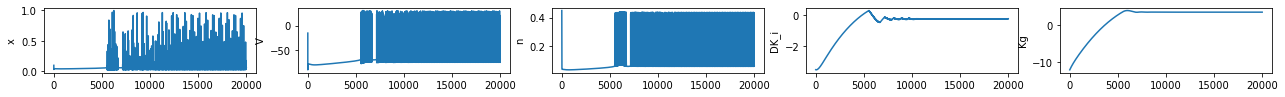

In [37]:
#J=10, Kb=9 (?)
fig, axs = plt.subplots(1, 5, figsize=(22,1.2))
axs[0].plot(t[::1], z[::1,0]);axs[0].set_ylabel('x')
axs[1].plot(t[::1], z[::1,1]);axs[1].set_ylabel('V')
axs[2].plot(t[::1], z[::1,2]);axs[2].set_ylabel('n')
axs[3].plot(t[::1], z[::1,3]); axs[3].set_ylabel('DK_i')
axs[4].plot(t[::1], z[::1,4]);axs[4].set_ylabel('Kg')
plt.show()

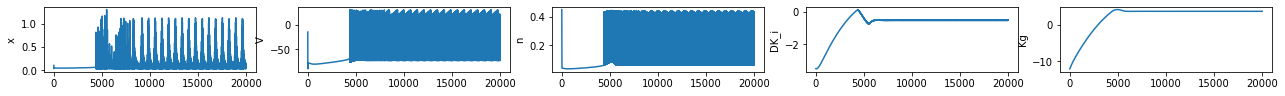

In [43]:
#J=10, Kb=10 (15.5)
fig, axs = plt.subplots(1, 5, figsize=(22,1.2))
axs[0].plot(t[::1], z[::1,0]);axs[0].set_ylabel('x')
axs[1].plot(t[::1], z[::1,1]);axs[1].set_ylabel('V')
axs[2].plot(t[::1], z[::1,2]);axs[2].set_ylabel('n')
axs[3].plot(t[::1], z[::1,3]); axs[3].set_ylabel('DK_i')
axs[4].plot(t[::1], z[::1,4]);axs[4].set_ylabel('Kg')
plt.show()

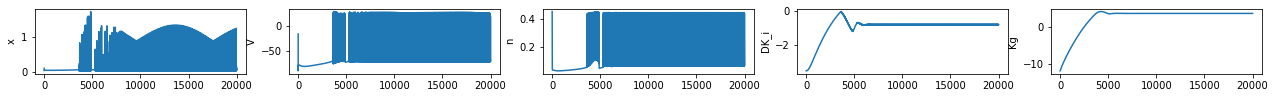

In [46]:
#J=10, Kb=11 (15.5)
fig, axs = plt.subplots(1, 5, figsize=(22,1.2))
axs[0].plot(t[::1], z[::1,0]);axs[0].set_ylabel('x')
axs[1].plot(t[::1], z[::1,1]);axs[1].set_ylabel('V')
axs[2].plot(t[::1], z[::1,2]);axs[2].set_ylabel('n')
axs[3].plot(t[::1], z[::1,3]); axs[3].set_ylabel('DK_i')
axs[4].plot(t[::1], z[::1,4]);axs[4].set_ylabel('Kg')
plt.show()

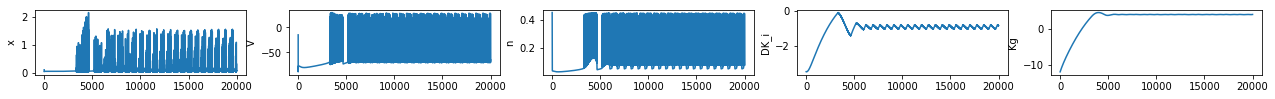

In [49]:
#J=10, Kb=11.5 (15.5)
fig, axs = plt.subplots(1, 5, figsize=(22,1.2))
axs[0].plot(t[::1], z[::1,0]);axs[0].set_ylabel('x')
axs[1].plot(t[::1], z[::1,1]);axs[1].set_ylabel('V')
axs[2].plot(t[::1], z[::1,2]);axs[2].set_ylabel('n')
axs[3].plot(t[::1], z[::1,3]); axs[3].set_ylabel('DK_i')
axs[4].plot(t[::1], z[::1,4]);axs[4].set_ylabel('Kg')
plt.show()

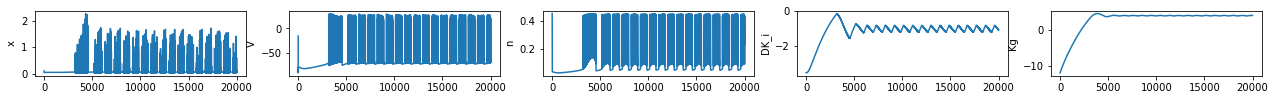

In [52]:
#J=10, Kb=11.75 (15.5)
fig, axs = plt.subplots(1, 5, figsize=(22,1.2))
axs[0].plot(t[::1], z[::1,0]);axs[0].set_ylabel('x')
axs[1].plot(t[::1], z[::1,1]);axs[1].set_ylabel('V')
axs[2].plot(t[::1], z[::1,2]);axs[2].set_ylabel('n')
axs[3].plot(t[::1], z[::1,3]); axs[3].set_ylabel('DK_i')
axs[4].plot(t[::1], z[::1,4]);axs[4].set_ylabel('Kg')
plt.show()

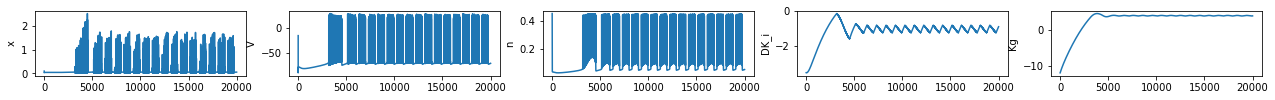

In [58]:
#J=10, Kb=11.8 (15.5)
fig, axs = plt.subplots(1, 5, figsize=(22,1.2))
axs[0].plot(t[::1], z[::1,0]);axs[0].set_ylabel('x')
axs[1].plot(t[::1], z[::1,1]);axs[1].set_ylabel('V')
axs[2].plot(t[::1], z[::1,2]);axs[2].set_ylabel('n')
axs[3].plot(t[::1], z[::1,3]); axs[3].set_ylabel('DK_i')
axs[4].plot(t[::1], z[::1,4]);axs[4].set_ylabel('Kg')
plt.show()

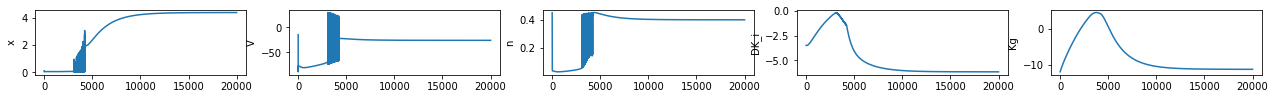

In [40]:
#J=10, Kb=12 (15.5)
fig, axs = plt.subplots(1, 5, figsize=(22,1.2))
axs[0].plot(t[::1], z[::1,0]);axs[0].set_ylabel('x')
axs[1].plot(t[::1], z[::1,1]);axs[1].set_ylabel('V')
axs[2].plot(t[::1], z[::1,2]);axs[2].set_ylabel('n')
axs[3].plot(t[::1], z[::1,3]); axs[3].set_ylabel('DK_i')
axs[4].plot(t[::1], z[::1,4]);axs[4].set_ylabel('Kg')
plt.show()

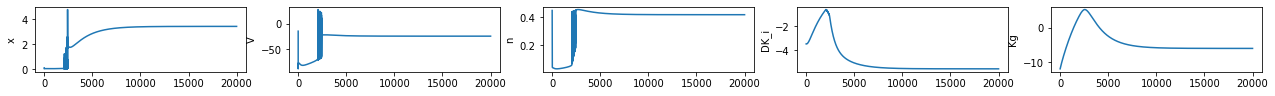

In [13]:
#J=10, Kb=8 (15.5)
fig, axs = plt.subplots(1, 5, figsize=(22,1.2))
axs[0].plot(t[::1], z[::1,0]);axs[0].set_ylabel('x')
axs[1].plot(t[::1], z[::1,1]);axs[1].set_ylabel('V')
axs[2].plot(t[::1], z[::1,2]);axs[2].set_ylabel('n')
axs[3].plot(t[::1], z[::1,3]); axs[3].set_ylabel('DK_i')
axs[4].plot(t[::1], z[::1,4]);axs[4].set_ylabel('Kg')
plt.show()

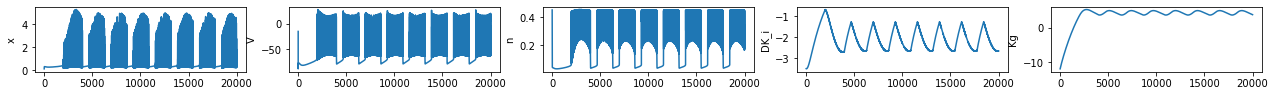

In [116]:
#J=10, Kb=15.5
fig, axs = plt.subplots(len(K_bath_vec), 5, figsize=(22,1.2))
for ik, k in enumerate(K_bath_vec):
    axs[0].plot(t[::1], z[::1,0]);axs[0].set_ylabel('x')
    axs[1].plot(t[::1], z[::1,1]);axs[1].set_ylabel('V')
    axs[2].plot(t[::1], z[::1,2]);axs[2].set_ylabel('n')
    axs[3].plot(t[::1], z[::1,3]); axs[3].set_ylabel('DK_i')
    axs[4].plot(t[::1], z[::1,4]);axs[4].set_ylabel('Kg')
plt.show()

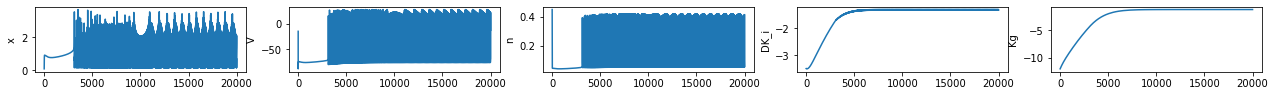

In [106]:
#J=10, Kb=7.5
fig, axs = plt.subplots(len(K_bath_vec), 5, figsize=(22,1.2))
for ik, k in enumerate(K_bath_vec):
    axs[0].plot(t[::1], z[::1,0]);axs[0].set_ylabel('x')
    axs[1].plot(t[::1], z[::1,1]);axs[1].set_ylabel('V')
    axs[2].plot(t[::1], z[::1,2]);axs[2].set_ylabel('n')
    axs[3].plot(t[::1], z[::1,3]); axs[3].set_ylabel('DK_i')
    axs[4].plot(t[::1], z[::1,4]);axs[4].set_ylabel('Kg')
plt.show()

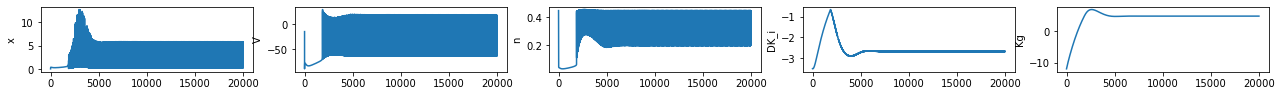

In [103]:
# J=1, Kb=17.5

fig, axs = plt.subplots(len(K_bath_vec), 5, figsize=(22,1.2))
for ik, k in enumerate(K_bath_vec):
    axs[0].plot(t[::1], z[::1,0]);axs[0].set_ylabel('x')
    axs[1].plot(t[::1], z[::1,1]);axs[1].set_ylabel('V')
    axs[2].plot(t[::1], z[::1,2]);axs[2].set_ylabel('n')
    axs[3].plot(t[::1], z[::1,3]); axs[3].set_ylabel('DK_i')
    axs[4].plot(t[::1], z[::1,4]);axs[4].set_ylabel('Kg')
plt.show()

# Parameter exploration

In [7]:
import pickle

def save_obj(obj, name ):
    with open('/Users/giovanni/Documents/GitHub/fufo/data/Interim/Abhirup/'+ name + '.pkl', 'wb') as f:
        pickle.dump(obj, f, pickle.HIGHEST_PROTOCOL)

In [141]:
# Parameter selection at bursts

K_bath_vec=np.linspace(3.5,27.5,97)

J_vec = [0.,0.1,1,10,100]
eta_vec = [0.]
Delta= 1.
Vstar=-31

iii=4

min_2_sim=1/3
min_2_cut=0
Np= int(min_2_sim*60*1000) #min in milliseconds 
Np_left= int(min_2_cut*60*1000) #min in milliseconds 
t = np.linspace(0,Np,Np*1)

z0 = [0.1,-15.0, 0.45, -3.5, -12.0]

Meanfield_KJ={}
for ik, k in enumerate(K_bath_vec):
    print(k)
    c_minus=Cm_c2[iii]*k**2+Cm_c1[iii]*k+Cm_c0[iii]
    c_plus=Cp_c2[iii]*k**2+Cp_c1[iii]*k+Cp_c0[iii]
    R_minus=Rm_c2[iii]*k**2+Rm_c1[iii]*k+Rm_c0[iii]
    R_plus=Rp_c2[iii]*k**2+Rp_c1[iii]*k+Rp_c0[iii]
    
    Meanfield_KJ[k]={} 
    for j in J_vec:
        Meanfield_KJ[k][j]={}
        z = odeint(mean_field_model,z0,t, args=(k,eta_vec[0],j,Delta,Vstar,c_minus,c_plus,R_minus,R_plus,))

        Meanfield_KJ[k][j]={} 
        Meanfield_KJ[k][j]['x']=z[:,0]
        Meanfield_KJ[k][j]['V']=z[:,1]
        Meanfield_KJ[k][j]['n']=z[:,2]
        Meanfield_KJ[k][j]['DK_i']=z[:,3]
        Meanfield_KJ[k][j]['Kg']=z[:,4]

        save_obj(Meanfield_KJ,'Meanfield_KJ')

3.5
5.5
7.5
9.5
11.5
13.5
15.5
17.5
19.5
21.5
23.5
25.5
27.5


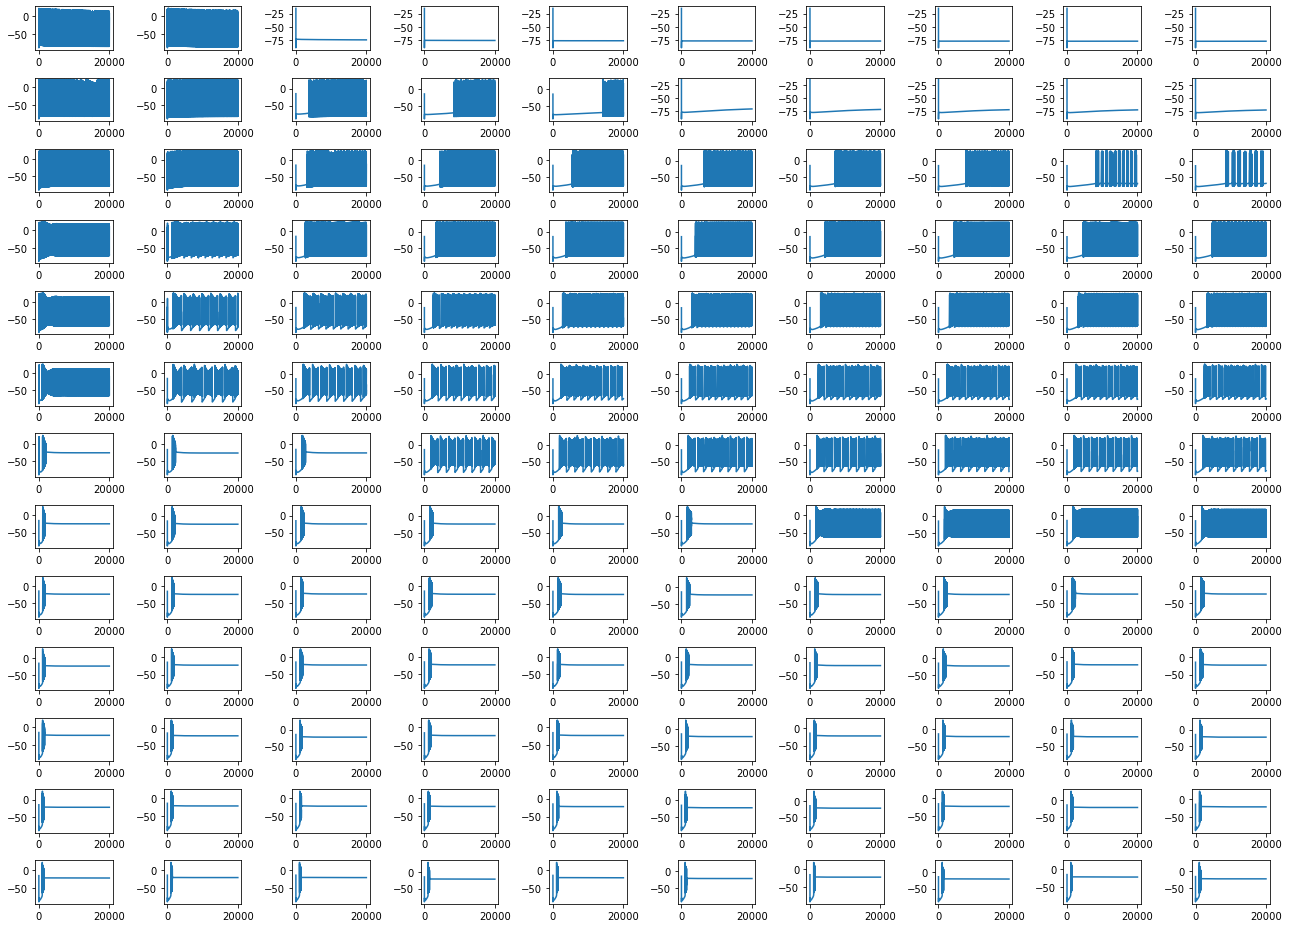

In [144]:
plt.figure(figsize=(18,13))
for ik, k in enumerate(K_bath_vec):
    for ij, j in enumerate(J_vec):
        plt.subplot(len(K_bath_vec),len(J_vec),len(J_vec)*ik+ij+1)
        plt.plot(Meanfield_[k][j]['V'])[::10]
plt.tight_layout()
plt.show()

# Single parameter example

In [28]:
J_vec = [1.]
eta_vec = [0.]
Delta= 1.

Vstar=-31
kb=15.5
iii=4
c_minus=Cm_c2[iii]*kb**2+Cm_c1[iii]*kb+Cm_c0[iii]
c_plus=Cp_c2[iii]*kb**2+Cp_c1[iii]*kb+Cp_c0[iii]
R_minus=Rm_c2[iii]*kb**2+Rm_c1[iii]*kb+Rm_c0[iii]
R_plus=Rp_c2[iii]*kb**2+Rp_c1[iii]*kb+Rp_c0[iii]

print(c_minus)

-61.23768116011395


In [29]:
K_bath_vec

array([ 3.5,  5.5,  7.5,  9.5, 11.5, 13.5, 15.5, 17.5, 19.5, 21.5, 23.5,
       25.5, 27.5])

In [30]:
z0 = [0.1,-15.0, 0.45, -3.5, -12.0]

min_2_sim=1/3
min_2_cut=0
Np= int(min_2_sim*60*1000) #min in milliseconds 
Np_left= int(min_2_cut*60*1000) #min in milliseconds 
t = np.linspace(0,Np,Np*1)

tic = time.time()
Meanfield={}

z = odeint(mean_field_model,z0,t, args=(kb, eta_vec[0],J_vec[0],Delta,Vstar,c_minus,c_plus,R_minus,R_plus,))

Meanfield[kb]={} 
Meanfield[kb]['x']=z[::10,0]
Meanfield[kb]['V']=z[::10,1]
Meanfield[kb]['n']=z[::10,2]
Meanfield[kb]['DK_i']=z[::10,3]
Meanfield[kb]['Kg']=z[::10,4]
tac = time.time()
elapsed_time = tac-tic
print('Elapsed time:')
time.strftime("%H:%M:%S", time.gmtime(elapsed_time))

Elapsed time:


'00:00:00'

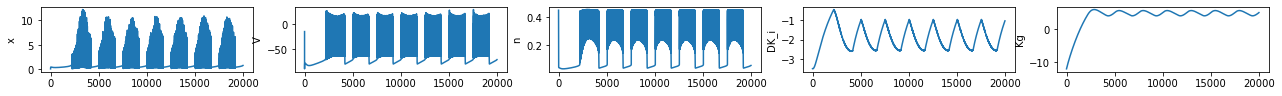

In [23]:
#J=1, Kb=15.5
fig, axs = plt.subplots(1, 5, figsize=(22,1.2))
axs[0].plot(t[::1], z[::1,0]);axs[0].set_ylabel('x')
axs[1].plot(t[::1], z[::1,1]);axs[1].set_ylabel('V')
axs[2].plot(t[::1], z[::1,2]);axs[2].set_ylabel('n')
axs[3].plot(t[::1], z[::1,3]); axs[3].set_ylabel('DK_i')
axs[4].plot(t[::1], z[::1,4]);axs[4].set_ylabel('Kg')
plt.show()

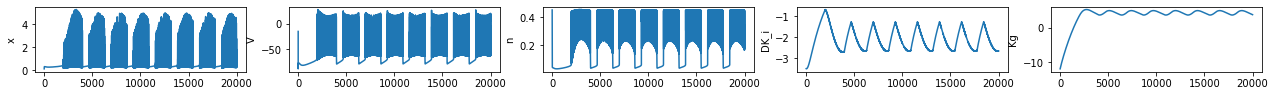

In [116]:
#J=10, Kb=15.5
fig, axs = plt.subplots(len(K_bath_vec), 5, figsize=(22,1.2))
for ik, k in enumerate(K_bath_vec):
    axs[0].plot(t[::1], z[::1,0]);axs[0].set_ylabel('x')
    axs[1].plot(t[::1], z[::1,1]);axs[1].set_ylabel('V')
    axs[2].plot(t[::1], z[::1,2]);axs[2].set_ylabel('n')
    axs[3].plot(t[::1], z[::1,3]); axs[3].set_ylabel('DK_i')
    axs[4].plot(t[::1], z[::1,4]);axs[4].set_ylabel('Kg')
plt.show()

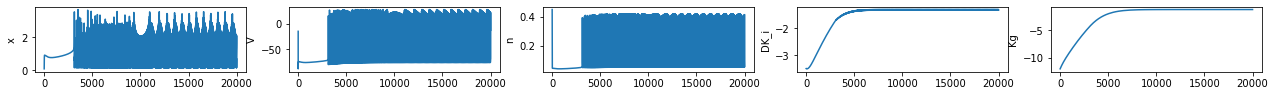

In [106]:
#J=10, Kb=7.5
fig, axs = plt.subplots(len(K_bath_vec), 5, figsize=(22,1.2))
for ik, k in enumerate(K_bath_vec):
    axs[0].plot(t[::1], z[::1,0]);axs[0].set_ylabel('x')
    axs[1].plot(t[::1], z[::1,1]);axs[1].set_ylabel('V')
    axs[2].plot(t[::1], z[::1,2]);axs[2].set_ylabel('n')
    axs[3].plot(t[::1], z[::1,3]); axs[3].set_ylabel('DK_i')
    axs[4].plot(t[::1], z[::1,4]);axs[4].set_ylabel('Kg')
plt.show()

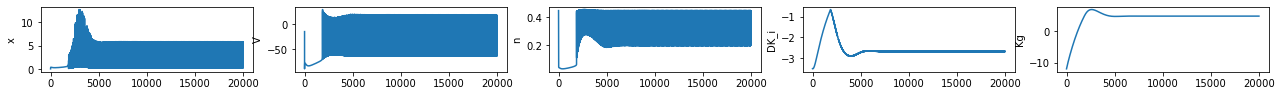

In [103]:
# J=1, Kb=17.5

fig, axs = plt.subplots(len(K_bath_vec), 5, figsize=(22,1.2))
for ik, k in enumerate(K_bath_vec):
    axs[0].plot(t[::1], z[::1,0]);axs[0].set_ylabel('x')
    axs[1].plot(t[::1], z[::1,1]);axs[1].set_ylabel('V')
    axs[2].plot(t[::1], z[::1,2]);axs[2].set_ylabel('n')
    axs[3].plot(t[::1], z[::1,3]); axs[3].set_ylabel('DK_i')
    axs[4].plot(t[::1], z[::1,4]);axs[4].set_ylabel('Kg')
plt.show()

In [13]:
# K_bath_vec=np.linspace(3.5,27.5,13)
# K_bath_vec

In [6]:
Cm_c2=[0.018181818180112153,0.019318181816369163,0.02045454545262617,0.02159090908888318,0.02272727272514019,0.0238636363613972,0.02499999999765421,0.026136363633911218,0.027272727270168228]
Cm_c1=[0.22317682317558613,0.23712537462406028,0.2510739260725344,0.26502247752100855,0.27897102896948267,0.2929195804179568,0.3068681318664309,0.3208166833149051,0.3347652347633792]
Cm_c0=[-57.21483516496188,-60.790762362772,-64.36668956058212,-67.94261675839223,-71.51854395620235,-75.09447115401247,-78.67039835182258,-82.2463255496327,-85.82225274744282]
Cp_c2=[-0.0174825174400573,-0.01857517478006088,-0.01966783212006446,-0.020760489460068043,-0.021853146800071624,-0.022945804140075205,-0.024038461480078786,-0.025131118820082367,-0.02622377616008595]
Cp_c1=[0.24085913945073179,0.25591283566640255,0.27096653188207326,0.28602022809774397,0.30107392431341473,0.3161276205290855,0.3311813167447562,0.3462350129604269,0.3612887091760977]
Cp_c0=[-8.954120869305608,-9.51375342363721,-10.07338597796881,-10.633018532300412,-11.192651086632011,-11.752283640963611,-12.311916195295213,-12.871548749626813,-13.431181303958414]
Rm_c2=[-8.253584557648197e-05,-8.76943359250121e-05,-9.285282627354222e-05,-9.801131662207235e-05,-0.00010316980697060247,-0.0001083282973191326,-0.00011348678766766272,-0.00011864527801619284,-0.00012380376836472297]
Rm_c1=[0.001715440103330407,0.0018226551097885574,0.001929870116246708,0.0020370851227048585,0.002144300129163009,0.002251515135621159,0.00235873014207931,0.0024659451485374603,0.0025731601549956106]
Rm_c0=[0.044183062400115575,0.0469445038001228,0.049705945200130025,0.05246738660013724,0.05522882800014447,0.057990269400151694,0.06075171080015891,0.06351315220016614,0.06627459360017336]
Rp_c2=[0.0001199379405135722,0.00012743406179567047,0.00013493018307776872,0.000142426304359867,0.00014992242564196526,0.0001574185469240635,0.0001649146682061618,0.00017241078948826004,0.0001799069107703583]
Rp_c1=[-0.0012775268840430581,-0.0013573723142957493,-0.0014372177445484404,-0.0015170631748011316,-0.0015969086050538228,-0.001676754035306514,-0.001756599465559205,-0.0018364448958118962,-0.0019162903260645874]
Rp_c0=[-0.08703834718009355,-0.0924782438788494,-0.09791814057760526,-0.1033580372763611,-0.10879793397511694,-0.11423783067387279,-0.11967772737262863,-0.1251176240713845,-0.13055752077014032]

In [27]:
# Finer
Cm_c2=[0.022118171681691213,0.023500557411796914,0.024882943141902612,0.026265328872008314,0.027647714602114015,0.029030100332219717,0.030412486062325418,0.031794871792431116,0.03317725752253682]
Cm_c1=[0.18325975473670358,0.19471348940774758,0.20616722407879154,0.21762095874983553,0.2290746934208795,0.24052842809192346,0.2519821627629674,0.2634358974340114,0.2748896321050554]
Cm_c0=[-57.14456187303638,-60.71609699010115,-64.28763210716592,-67.8591672242307,-71.43070234129547,-75.00223745836024,-78.57377257542502,-82.1453076924898,-85.71684280955456]
Cp_c2=[-0.01841694559121968,-0.019568004690670913,-0.020719063790122144,-0.021870122889573372,-0.023021181989024603,-0.024172241088475835,-0.025323300187927063,-0.026474359287378294,-0.027625418386829526]
Cp_c1=[0.21215608298849667,0.22541583817527772,0.23867559336205874,0.2519353485488398,0.26519510373562083,0.27845485892240185,0.2917146141091829,0.30497436929596394,0.318234124482745]
Cp_c0=[-8.434066936318345,-8.961196119838242,-9.488325303358138,-10.015454486878035,-10.542583670397931,-11.069712853917828,-11.596842037437725,-12.123971220957621,-12.651100404477518]
Rm_c2=[-0.0008101388464166427,-0.0008607725243176829,-0.000911406202218723,-0.0009620398801197631,-0.0010126735580208034,-0.0010633072359218436,-0.0011139409138228836,-0.0011645745917239238,-0.001215208269624964]
Rm_c1=[0.01594602815125314,0.01694265491070646,0.01793928167015978,0.018935908429613103,0.019932535189066423,0.020929161948519744,0.021925788707973067,0.022922415467426387,0.023919042226879707]
Rm_c0=[0.45096549444735956,0.47915083785031953,0.5073361812532795,0.5355215246562395,0.5637068680591995,0.5918922114621594,0.6200775548651194,0.6482628982680794,0.6764482416710393]
Rp_c2=[0.0012162642446936984,0.0012922807599870544,0.0013682972752804105,0.0014443137905737668,0.001520330305867123,0.001596346821160479,0.0016723633364538353,0.0017483798517471914,0.0018243963670405475]
Rp_c1=[-0.011225135024886942,-0.011926705963942377,-0.012628276902997811,-0.013329847842053244,-0.014031418781108678,-0.014732989720164113,-0.015434560659219545,-0.01613613159827498,-0.016837702537330412]
Rp_c0=[-0.8860034274629699,-0.9413786416794055,-0.9967538558958411,-1.0521290701122767,-1.1075042843287124,-1.162879498545148,-1.2182547127615837,-1.2736299269780194,-1.3290051411944548]